# 03 — Validación sintético vs donor_validation

Carga los **3 parquets** (seeds 42, 123, 2026). Incluye:

1. **Agregado** — 15.000 ventanas juntas vs validation
2. **Por semilla** — MMD, marginales y PCA de cada seed por separado

**No usar NVDA visible/test.**

In [30]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

from src.data import CHANNELS, load_donor_windows, windows_to_array
from src.metrics import (
    compare_parquet_splits,
    per_seed_mmd_summary,
    per_seed_validation_summary,
    save_validation_report,
)
from src.paths import default_windows_dir, outputs_dir
from src.synthetic_io import load_synthetic_parquets, official_seeds, split_synthetic_by_seed

sns.set_theme(style="whitegrid")

PLOT_RNG = np.random.default_rng(42)


def subsample_windows(windows: np.ndarray, n: int, rng: np.random.Generator = PLOT_RNG) -> np.ndarray:
    """Subsample for plots so synthetic does not overwhelm real points."""
    if len(windows) <= n:
        return windows
    idx = rng.choice(len(windows), size=n, replace=False)
    return windows[idx]


In [31]:
synthetic, synthetic_paths = load_synthetic_parquets(seeds=official_seeds())
validation = load_donor_windows("donor_validation", windows_dir=default_windows_dir())

X_syn = windows_to_array(synthetic)
X_val = windows_to_array(validation)

print("Parquets sintéticos (3 seeds):")
for path in synthetic_paths:
    print(f"  - {path.name}")
print(f"Total sintético: {len(X_syn)} ventanas ({len(synthetic_paths)} seeds × {len(X_syn) // len(synthetic_paths)})")
print(f"Validation: {len(X_val)} ventanas")

Parquets sintéticos (3 seeds):
  - synthetic_seed42_n5000.parquet
  - synthetic_seed123_n5000.parquet
  - synthetic_seed2026_n5000.parquet
Total sintético: 15000 ventanas (3 seeds × 5000)
Validation: 380 ventanas


In [32]:
print("=== Agregado (3 seeds juntas) ===")
report_all = compare_parquet_splits(validation, synthetic)
print(f"MMD (flat): {report_all.mmd_flat:.6f}")
display(report_all.channel_summary_real)
display(report_all.channel_summary_synthetic)
display(report_all.autocorr_real)
display(report_all.autocorr_synthetic)

report_path = outputs_dir() / "synthetic_all_seeds.validation.json"
save_validation_report(report_all, report_path)
print(f"Informe agregado -> {report_path}")

=== Agregado (3 seeds juntas) ===
MMD (flat): 0.008131


,channel,mean,std,min,max
0,log_return,-0.001630,0.029279,-0.149299,0.149978
1,log_high_low_range,0.036210,0.015943,0.009586,0.128724
2,log1p_volume,16.219625,1.115950,13.508171,19.233361


,channel,mean,std,min,max
0,log_return,0.000919,0.021766,-0.291213,0.333679
1,log_high_low_range,0.025870,0.015990,-0.014030,0.307610
2,log1p_volume,16.008256,1.094001,12.251064,22.287950


,channel,autocorr_lag1_mean,autocorr_lag1_std
0,log_return,-0.058412,0.099226
1,log_high_low_range,0.072556,0.096640
2,log1p_volume,0.362559,0.152487


,channel,autocorr_lag1_mean,autocorr_lag1_std
0,log_return,-0.044381,0.145912
1,log_high_low_range,0.256599,0.171696
2,log1p_volume,0.475865,0.133672


Informe agregado -> /home/cristian/Documents/miax/modulo5/2026_Modelos_generativos/taller/taller_cristian/generadores/cristian/outputs/synthetic_all_seeds.validation.json


## Análisis por semilla

Compara cada parquet sintético (seed 42, 123, 2026) frente a `donor_validation` por separado.

In [33]:
per_seed_mmd = per_seed_mmd_summary(validation, synthetic)
per_seed_detail = per_seed_validation_summary(validation, synthetic)

display(per_seed_mmd.sort_values("seed"))
print("MMD por seed — menor suele ser mejor ajuste vs validation.")

per_seed_report_path = outputs_dir() / "synthetic_by_seed.validation.json"
per_seed_report_path.write_text(
    per_seed_detail.to_json(orient="records", indent=2),
    encoding="utf-8",
)
print(f"Detalle por seed -> {per_seed_report_path}")

,seed,n_synthetic,mmd_flat
0,42,5000,0.005786
1,123,5000,0.014741
2,2026,5000,0.009423


MMD por seed — menor suele ser mejor ajuste vs validation.
Detalle por seed -> /home/cristian/Documents/miax/modulo5/2026_Modelos_generativos/taller/taller_cristian/generadores/cristian/outputs/synthetic_by_seed.validation.json


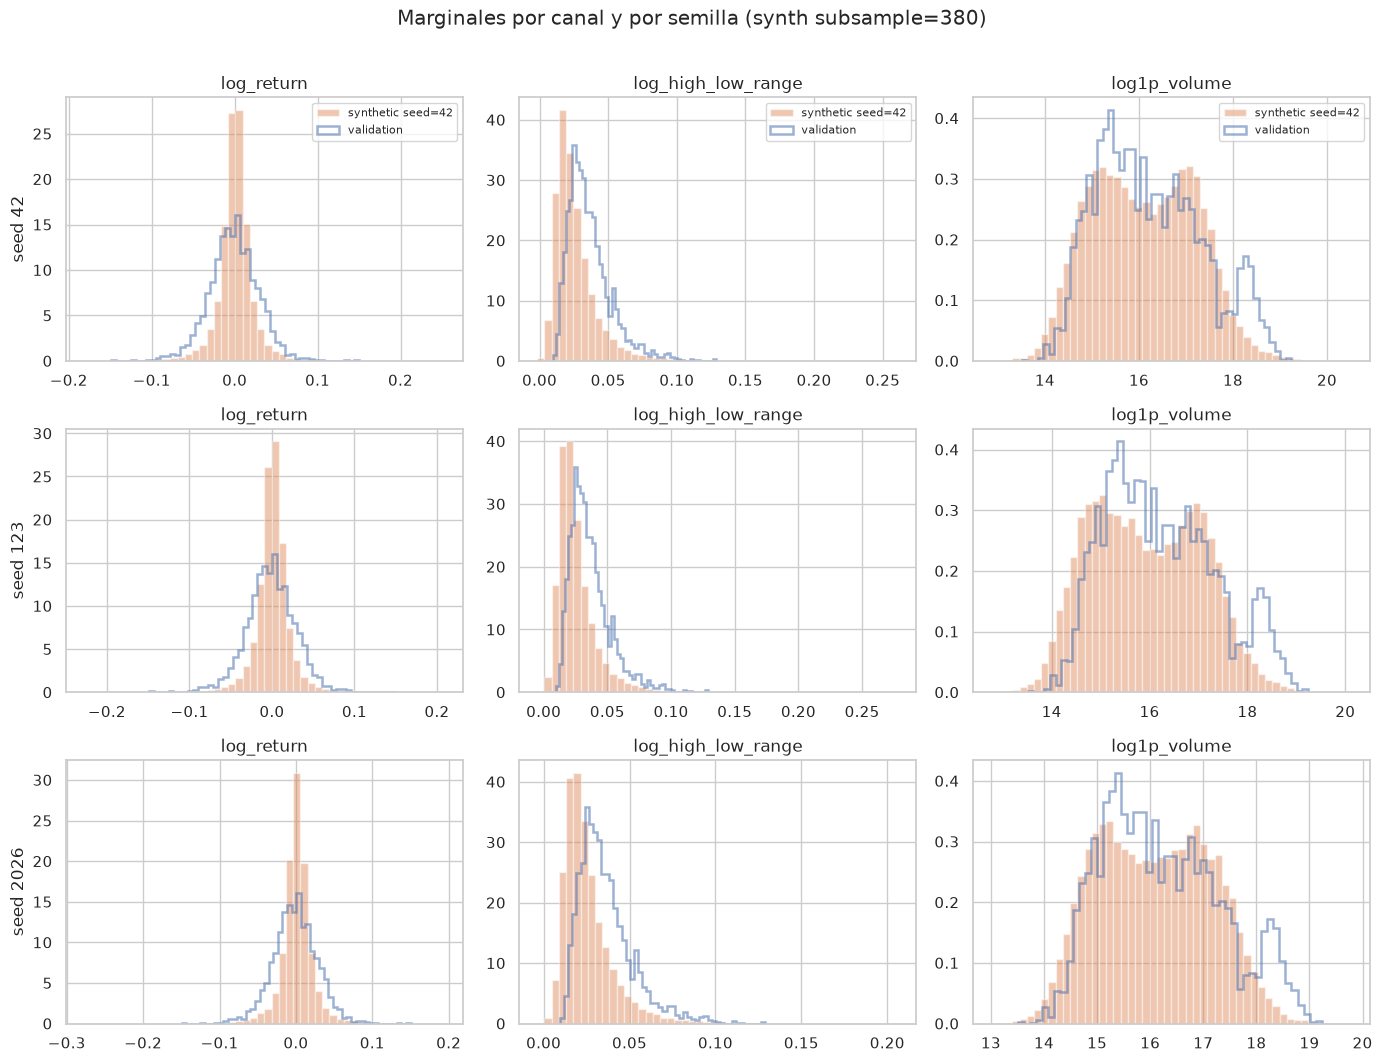

In [34]:
synthetic_by_seed = split_synthetic_by_seed(synthetic)
seeds = sorted(synthetic_by_seed)
n_plot = len(X_val)

fig, axes = plt.subplots(len(seeds), 3, figsize=(14, 3.5 * len(seeds)), sharex=False)
if len(seeds) == 1:
    axes = np.array([axes])

for row, seed in enumerate(seeds):
    X_seed = subsample_windows(windows_to_array(synthetic_by_seed[seed]), n_plot)
    for col, name in enumerate(CHANNELS):
        ax = axes[row, col]
        # synthetic primero; validation encima para que no quede oculta
        ax.hist(X_seed[:, :, col].reshape(-1), bins=50, alpha=0.45, label=f"synthetic seed={seed}", density=True, color="C1")
        ax.hist(X_val[:, :, col].reshape(-1), bins=50, alpha=0.55, label="validation", density=True, color="C0", histtype="step", linewidth=1.8)
        ax.set_title(name)
        if col == 0:
            ax.set_ylabel(f"seed {seed}")
        if row == 0:
            ax.legend(fontsize=8)

plt.suptitle(f"Marginales por canal y por semilla (synth subsample={n_plot})", y=1.01)
plt.tight_layout()


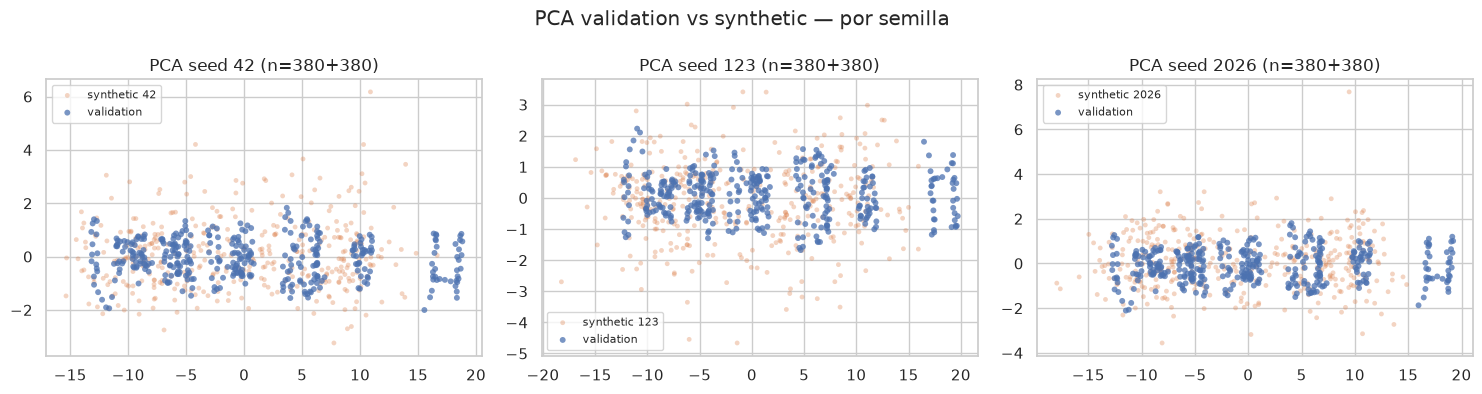

In [35]:
fig, axes = plt.subplots(1, len(seeds), figsize=(5 * len(seeds), 4))
if len(seeds) == 1:
    axes = [axes]

n_plot = len(X_val)
for ax, seed in zip(axes, seeds):
    X_seed = subsample_windows(windows_to_array(synthetic_by_seed[seed]), n_plot)
    flat_val = X_val.reshape(len(X_val), -1)
    flat_seed = X_seed.reshape(len(X_seed), -1)
    combined = np.vstack([flat_val, flat_seed])
    labels = np.array(["validation"] * len(flat_val) + [f"synthetic {seed}"] * len(flat_seed))

    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(combined)

    # synthetic first, validation on top
    for label, color, zorder, alpha, size in [
        (f"synthetic {seed}", "C1", 1, 0.35, 12),
        ("validation", "C0", 3, 0.75, 18),
    ]:
        mask = labels == label
        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=size,
            alpha=alpha,
            label=label,
            c=color,
            zorder=zorder,
            edgecolors="none",
        )
    ax.set_title(f"PCA seed {seed} (n={n_plot}+{n_plot})")
    ax.legend(fontsize=8)

plt.suptitle("PCA validation vs synthetic — por semilla")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_por_seed.png", dpi=140, bbox_inches="tight")


## Agregado — visualización conjunta (3 seeds)

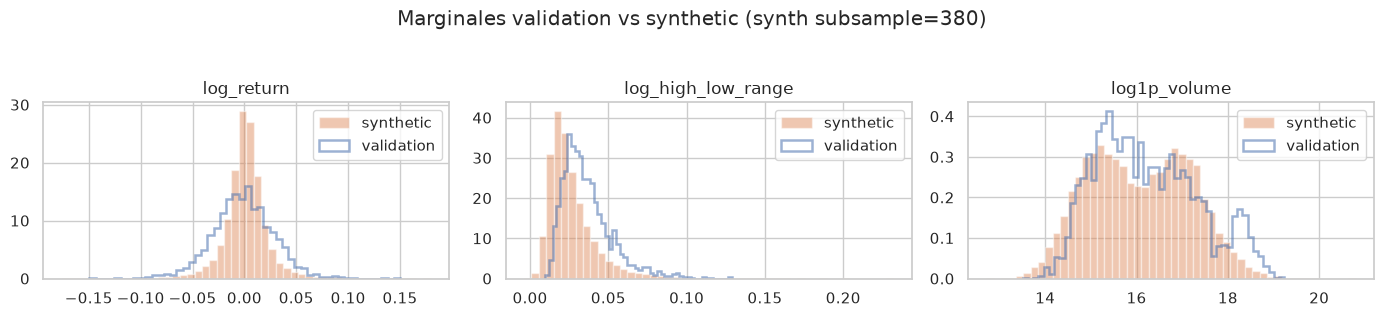

In [36]:
n_plot = len(X_val)
X_syn_plot = subsample_windows(X_syn, n_plot)

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, idx, name in zip(axes, range(3), CHANNELS):
    ax.hist(X_syn_plot[:, :, idx].reshape(-1), bins=50, alpha=0.45, label="synthetic", density=True, color="C1")
    ax.hist(X_val[:, :, idx].reshape(-1), bins=50, alpha=0.55, label="validation", density=True, color="C0", histtype="step", linewidth=1.8)
    ax.set_title(name)
    ax.legend()
plt.suptitle(f"Marginales validation vs synthetic (synth subsample={n_plot})", y=1.05)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dist_donor_val_vs_sintetico.png", dpi=140, bbox_inches="tight")


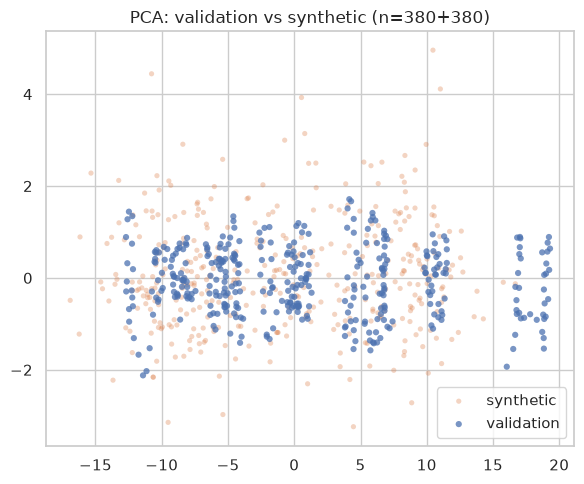

In [37]:
n_plot = len(X_val)
X_syn_plot = subsample_windows(X_syn, n_plot)

flat_val = X_val.reshape(len(X_val), -1)
flat_syn = X_syn_plot.reshape(len(X_syn_plot), -1)
combined = np.vstack([flat_val, flat_syn])
labels = np.array(["validation"] * len(flat_val) + ["synthetic"] * len(flat_syn))

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(combined)

plt.figure(figsize=(6, 5))
for label, color, zorder, alpha, size in [
    ("synthetic", "C1", 1, 0.35, 14),
    ("validation", "C0", 3, 0.75, 20),
]:
    mask = labels == label
    plt.scatter(
        coords[mask, 0],
        coords[mask, 1],
        s=size,
        alpha=alpha,
        label=label,
        c=color,
        zorder=zorder,
        edgecolors="none",
    )
plt.legend()
plt.title(f"PCA: validation vs synthetic (n={n_plot}+{n_plot})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_donor_val_vs_sintetico.png", dpi=140, bbox_inches="tight")


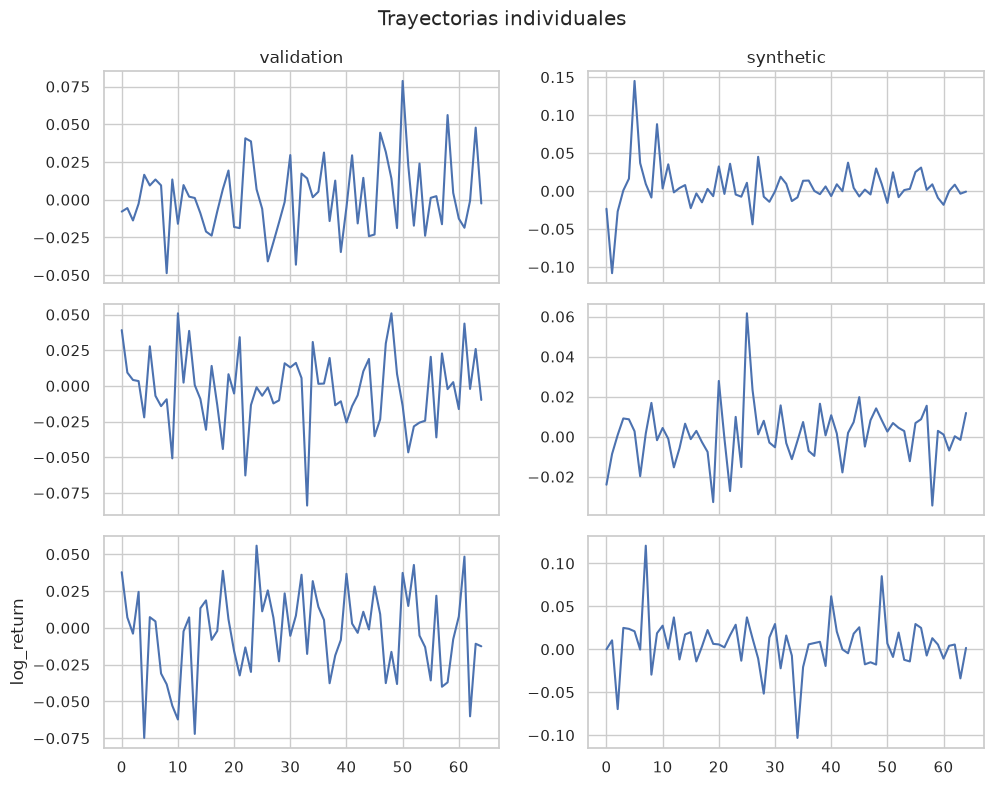

In [38]:
rng = np.random.default_rng(42)
idx_val = rng.choice(len(X_val), 3)
idx_syn = rng.choice(len(X_syn), 3)

fig, axes = plt.subplots(3, 2, figsize=(10, 8), sharex=True)
for row in range(3):
    axes[row, 0].plot(X_val[idx_val[row], :, 0])
    axes[row, 1].plot(X_syn[idx_syn[row], :, 0])
    if row == 0:
        axes[row, 0].set_title("validation")
        axes[row, 1].set_title("synthetic")
axes[row, 0].set_ylabel("log_return")
plt.suptitle("Trayectorias individuales")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "trayectorias_val_vs_sintetico.png", dpi=140, bbox_inches="tight")
